### Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Load Gambar

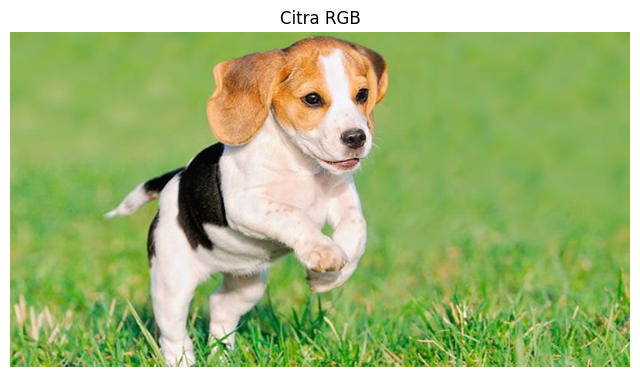

In [2]:
image = cv2.imread("anjing.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.title("Citra RGB")
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

### Segmentasi Warna (HSV)

(-0.5, 757.5, 409.5, -0.5)

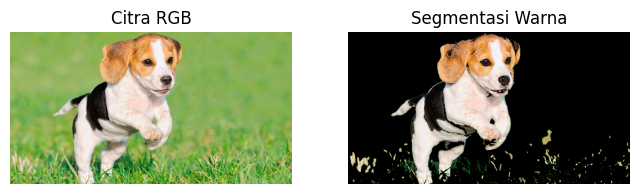

In [8]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# rentang warna putih
lw = np.array([0, 0, 150])
uw = np.array([180, 80, 255])
mask_white = cv2.inRange(hsv, lw, uw)

# rentang warna cokelat
lb = np.array([5, 50, 150])
ub = np.array([30, 255, 255])
mask_brown = cv2.inRange(hsv, lb, ub)

# rentang warna hitam
lk = np.array([0, 0, 0])
uk = np.array([180, 255, 100])
mask_black = cv2.inRange(hsv, lk, uk)

# Gabungan mask
mask_color = mask_white | mask_brown | mask_black
seg_color = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_color)

plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
plt.title("Citra RGB")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmentasi Warna")
plt.imshow(seg_color)
plt.axis("off")

### Morphologi erosi

(-0.5, 757.5, 409.5, -0.5)

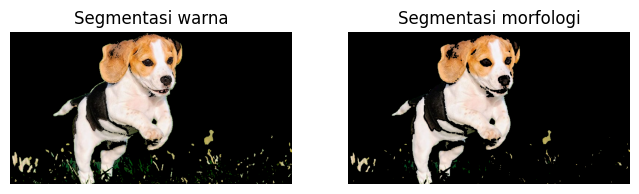

In [12]:
kernel = np.ones((3,3), np.uint8)
mask_erode = cv2.erode(mask_color, kernel, iterations=1)

seg_eroded = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_erode)

plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
plt.title("Segmentasi warna")
plt.imshow(seg_color)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmentasi morfologi")
plt.imshow(seg_eroded)
plt.axis("off")

### Contour Detection

(-0.5, 757.5, 409.5, -0.5)

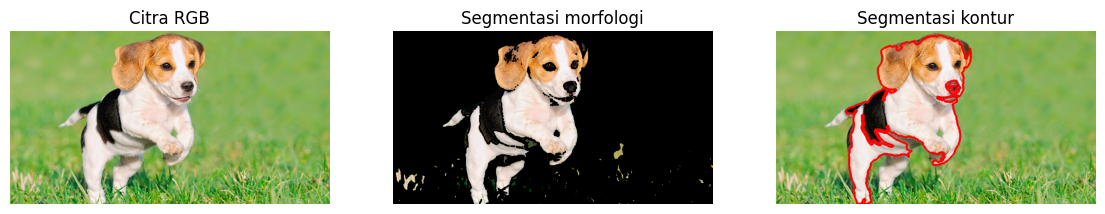

In [20]:
contours, hierarchy = cv2.findContours(mask_erode, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 2500:
        x, y, w, h = cv2.boundingRect(cnt)
        rasio = w / float(h)
        if 0.3 < rasio < 3.2:
            filtered.append(cnt)

contour_img = image_rgb.copy()
cv2.drawContours(contour_img, filtered, -1, (255, 0, 0), 3)

plt.figure(figsize=(14,8))
plt.subplot(1,3,1)
plt.title("Citra RGB")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Segmentasi morfologi")
plt.imshow(seg_eroded)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Segmentasi kontur")
plt.imshow(contour_img)
plt.axis("off")
plt.show()